# Figure making code for `pinn-v2`

In [1]:
import sys
sys.path.append('../src')

import absl.logging
absl.logging.set_verbosity(absl.logging.ERROR)

import matplotlib.pyplot as plt
plt.style.core.USER_LIBRARY_PATHS.append('/gscratch/matsulab/utils/ctleelab-mpl-utilities/ctleelab_plothelper')
plt.style.reload_library()

sys.path.append('../../../utils')
from fonts.mpl_fonts import set_arial_font
set_arial_font()

[mpl_fonts] Using font: Arial
[mpl_fonts] Font dir: /mmfs1/gscratch/matsulab/utils/fonts


In [2]:
## To reload

import importlib
# import pinn.plot as plot
# import data_generation.preprocess as preprocess
# import pinn.utils as utils
# import pinn.analysis as analysis
import pinn.normal_curves as normal

# importlib.reload(plot)
# importlib.reload(utils)
# importlib.reload(preprocess)
# importlib.reload(analysis)
importlib.reload(normal)

<module 'pinn.normal_curves' from '/mmfs1/gscratch/matsulab/sim/pinn-exploration-model/notebooks/../src/pinn/normal_curves.py'>

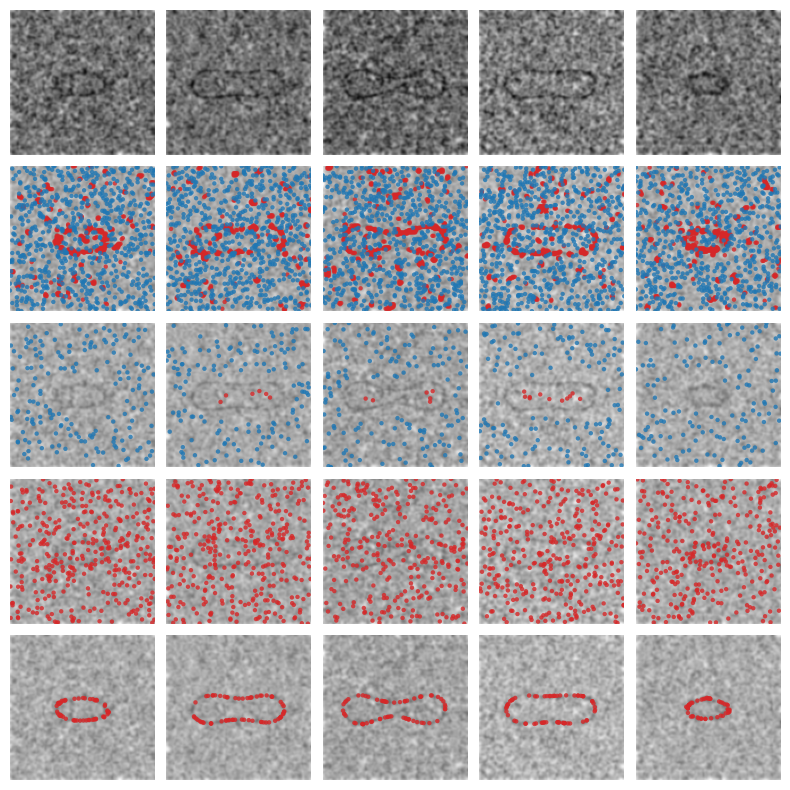

In [5]:
## FIGURE 2B (Input Images)

import os
import numpy as np
import matplotlib.pyplot as plt
from pinn.cryoet_io import load_mrc_data
from data_generation.preprocess import overlay_points_on_cryoet_ax
from pinn.utils import load_pts_data
from pinn.plot import show_cryoet_slice

import mrcfile
import jax
import jax.numpy as jnp

# ==== Parameters =====
GRID_SIZE = 128
shape = "biconcave"
additive = 0.1
missing  = 0.7
str_add = f"{additive:.2f}".replace('.', '')
str_miss = f"{missing:.1f}".replace('.', '')
lambda_1 = 100000
lambda_2 = 1
lambda_3 = 100000

slice_index_list = [24, 44, 64, 84, 104]
axis = "z"
pts_size=10

# ==== Load point data =====
pts_path = f"../data/synthetic/pts"
edge = load_pts_data(f"{pts_path}/edge/e_{shape}_a{str_add}_m{str_miss}_g{GRID_SIZE}.npz", perm=(0,1,2))
sign = load_pts_data(f"{pts_path}/sign/s_{shape}.npz", perm=(0,1,2))
phys = load_pts_data(f"{pts_path}/phys/p_{shape}.npz", perm=(0,1,2))
curv = load_pts_data(f"{pts_path}/curv/a{str_add}_m{str_miss}_g{GRID_SIZE}/c_{shape}_{lambda_1}_{lambda_2}_{lambda_3}.npz", perm=(0,1,2))

# ==== Load CryoET data =====
mrc_file_path = f"../data/synthetic/mrc/{shape}_a{str_add}_m{str_miss}.mrc"
cryoET_data = load_mrc_data(mrc_file_path, grid_size=GRID_SIZE)

n_col = len(slice_index_list)
n_row = 5
fig = plt.figure(figsize=(2*n_col, 2*n_row))

fig.subplots_adjust(
    wspace=0.05,   # width space (fraction of axes)
    hspace=0.08,   # height space
)

plt.style.reload_library()
with plt.style.context(["base", "transparent"]):

    # Row 1: 
    for i, slice in enumerate(slice_index_list):
        ax = fig.add_subplot(n_row, n_col, i+1)
        overlay_points_on_cryoet_ax(ax, cryoet=cryoET_data, axis=axis, slice_index=slice)

    # Row 2:
    for i, slice in enumerate(slice_index_list):
        ax = fig.add_subplot(n_row, n_col, 1*n_col+i+1)
        pt_e = edge["points"][edge["label"] == 1][:, [2, 0, 1]]
        pt_b = edge["points"][edge["label"] == 0][:, [2, 0, 1]]
        overlays = [
            {"data": pt_e, "label": "Edge", "color": "tab:red"},
            {"data": pt_b, "label": "Bulk", "color": "tab:blue"},
        ]
        overlay_points_on_cryoet_ax(ax, cryoet=cryoET_data, overlays=overlays, axis=axis, slice_index=slice, pts_size=pts_size, cryo_alpha=0.6)

    # Row 3:
    for i, slice in enumerate(slice_index_list):
        ax = fig.add_subplot(n_row, n_col, 2*n_col+i+1)
        pt_p = sign["points"][sign["label"] ==  1][:, [2, 0, 1]]
        pt_n = sign["points"][sign["label"] == -1][:, [2, 0, 1]]
        overlays = [
            {"data": pt_p, "label": "Phi = +1", "color": "tab:red"},
            {"data": pt_n, "label": "Phi = -1", "color": "tab:blue"},
        ]
        overlay_points_on_cryoet_ax(ax, cryoet=cryoET_data, overlays=overlays, axis=axis, slice_index=slice, pts_size=pts_size, cryo_alpha=0.6)

    # Row 4:
    for i, slice in enumerate(slice_index_list):
        ax = fig.add_subplot(n_row, n_col, 3*n_col+i+1)
        pt_p = phys["points"][:, [2, 0, 1]]
        overlays = [
            {"data": pt_p, "label": "Physics", "color": "tab:red"},
        ]
        overlay_points_on_cryoet_ax(ax, cryoet=cryoET_data, overlays=overlays, axis=axis, slice_index=slice, pts_size=pts_size, cryo_alpha=0.6)

    # Row 5:
    for i, slice in enumerate(slice_index_list):
        ax = fig.add_subplot(n_row, n_col, 4*n_col+i+1)
        pt_c = curv["points"][:, [2, 0, 1]]
        overlays = [
            {"data": pt_c, "label": "Curvs", "color": "tab:red"},
        ]
        overlay_points_on_cryoet_ax(ax, cryoet=cryoET_data, overlays=overlays, axis=axis, slice_index=slice, pts_size=pts_size, cryo_alpha=0.6)

    save_path = f"../outputs/figs/v_0321/synth/{shape}_a{str_add}_m{str_miss}_g{GRID_SIZE}"
    os.makedirs(save_path, exist_ok=True)
    plt.savefig(f"{save_path}/input.png", bbox_inches="tight")
    plt.show()

In [11]:
## FIGURE 2C (Loss Progress)
## Load data

import os
import numpy as np
import matplotlib.pyplot as plt
from flax.training import checkpoints
from pinn.utils import load_loss_history_dir, concat_histories
from pinn.plot import plot_loss_panels

# ==== Parameters =====
lambda_1 = 100000
lambda_2 = 1
lambda_3 = 100000
lambda_4 = 10
shape_list = ["biconcave", "bud_04"]
# shape_list = ["bud_04"]
steps_series = list(range(0, 10001, 100))
phase_list = [0,1,2]

additive = 0.1
missing  = 0.7
str_add = f"{additive:.2f}".replace('.', '')
str_miss = f"{missing:.1f}".replace('.', '')
version  = "data_0321"
grid_size = 128

# ==== Load data =====
assembled_loss = {}

for shape in shape_list:
    assembled_loss[shape] = {}
    root_dir = f"../outputs/logs/{shape}/{version}/a{str_add}_m{str_miss}_g{grid_size}"

    merged_history = None

    for phase in phase_list:
        print(f"Loading {shape}, phase {phase}...")

        if phase == 0:
            _lambda_2 = 0
            _lambda_4 = 0
            offset = 0
        elif phase == 1:
            _lambda_2 = lambda_2
            _lambda_4 = 0
            offset = 10000
        elif phase == 2:
            _lambda_2 = lambda_2
            _lambda_4 = lambda_4
            offset = 20000

        ckpt_dir = os.path.abspath(f"{root_dir}/phase{phase}_{lambda_1}_{_lambda_2}_{lambda_3}_{_lambda_4}")
        steps = list(range(0, 10001, 100))

        history = load_loss_history_dir(ckpt_dir, steps, step_offset=offset)

        if merged_history is None:
            merged_history = history
        else:
            merged_history = concat_histories(merged_history, history)

    assembled_loss[shape] = merged_history


# fig, axes = plot_loss_panels(assembled_loss, shape_list, lambda_2_list)
# plt.show(fig)

Loading biconcave, phase 0...
Loading biconcave, phase 1...
Loading biconcave, phase 2...
Loading bud_04, phase 0...
Loading bud_04, phase 1...
Loading bud_04, phase 2...


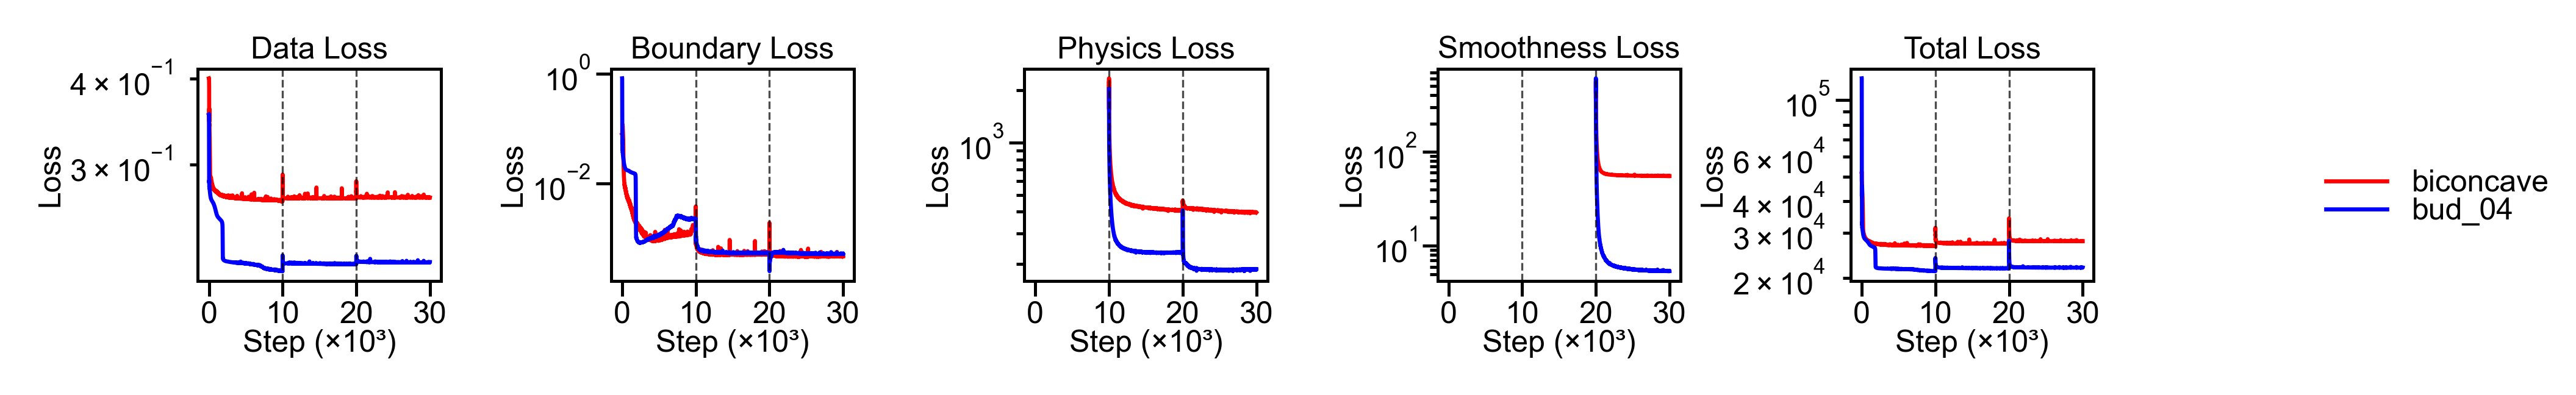

In [42]:
## FIGURE 2C (Loss Progress)
## Plot figures
from pinn.analysis import plot_loss_panels

plt.style.reload_library()
with plt.style.context(["base", "transparent"]):
    fig, axes = plot_loss_panels(assembled_loss, 
                                 shape_list,
                                 figsize=(7.0, 1),
                                 show_legend=True,
                                 smooth_window=3,
                                 logscale_keys=["data_loss", "sign_loss", "phys_loss", "curv_loss", "total_loss"],
                                )
    fig.subplots_adjust(bottom=0.3)  # try 0.30–0.45

    save_dir = f"../outputs/figs/v_0321/synth"
    os.makedirs(save_dir, exist_ok=True)
    # fig.savefig(f"{save_dir}/loss_prog_a{str_add}_m{str_miss}_g{GRID_SIZE}_l{lambda_1}-{lambda_2}-{lambda_3}-{lambda_4}.pdf", dpi=600, bbox_inches=None)
    plt.show(fig)

/mmfs1/gscratch/matsulab/sim/pinn-exploration-model/outputs/logs/biconcave/data_0321/a010_m07_g128/phase0_100000_0_100000_0/checkpoint_0
/mmfs1/gscratch/matsulab/sim/pinn-exploration-model/outputs/logs/biconcave/data_0321/a010_m07_g128/phase0_100000_0_100000_0/checkpoint_200
/mmfs1/gscratch/matsulab/sim/pinn-exploration-model/outputs/logs/biconcave/data_0321/a010_m07_g128/phase0_100000_0_100000_0/checkpoint_1000
/mmfs1/gscratch/matsulab/sim/pinn-exploration-model/outputs/logs/biconcave/data_0321/a010_m07_g128/phase1_100000_1_100000_0/checkpoint_0
/mmfs1/gscratch/matsulab/sim/pinn-exploration-model/outputs/logs/biconcave/data_0321/a010_m07_g128/phase2_100000_1_100000_10/checkpoint_0
/mmfs1/gscratch/matsulab/sim/pinn-exploration-model/outputs/logs/biconcave/data_0321/a010_m07_g128/phase2_100000_1_100000_10/checkpoint_10000
/mmfs1/gscratch/matsulab/sim/pinn-exploration-model/outputs/logs/bud_04/data_0321/a010_m07_g128/phase0_100000_0_100000_0/checkpoint_0
/mmfs1/gscratch/matsulab/sim/pinn

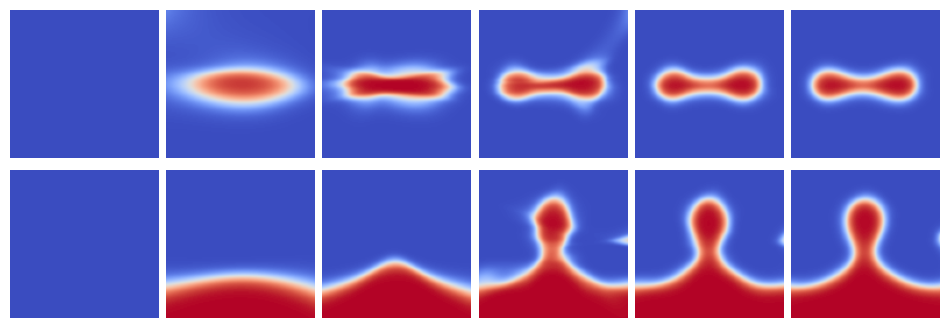

In [40]:
## FIGURE 2D (Phase Field Progress)

import os
import numpy as np
import matplotlib.pyplot as plt
from flax.training import checkpoints
from pinn.cryoet_io import load_mrc_data
from pinn.plot import visualize_cryoET_with_contours, visualize_phase

import mrcfile
import jax
import jax.numpy as jnp

# ==== Parameters =====
GRID_SIZE = 128
lambda_1 = 100000
lambda_2 = 1
lambda_3 = 100000
lambda_4 = 10
shape_list = ["biconcave", "bud_04"]
step_list = [0, 200, 1000, 10000, 20000, 30000]
epsilon = 0.05
slice_index = 64
additive = 0.1
missing  = 0.7
str_add = f"{additive:.2f}".replace('.', '')
str_miss = f"{missing:.1f}".replace('.', '')
axis = "z"
ckpt = {}

# =========================
# Load checkpoints
# =========================
for shape in shape_list:
    ckpt[shape] = {}

    for step in step_list:

        if step < 10000:
            phase = 0
            _step = step
            _lambda_2 = 0
            _lambda_4 = 0
        
        elif step < 20000:
            phase = 1
            _step = step - 10000
            _lambda_2 = lambda_2
            _lambda_4 = 0
        
        elif step <= 30000:
            phase = 2
            _step = step - 20000
            _lambda_2 = lambda_2
            _lambda_4 = lambda_4
        
        else:
            raise ValueError(f"step out of range: {step}")

        checkpoint_dir = (
            f"../outputs/logs/{shape}/data_0321/"
            f"a{str_add}_m{str_miss}_g{GRID_SIZE}/"
            f"phase{phase}_{lambda_1}_{_lambda_2}_{lambda_3}_{_lambda_4}/"
            f"checkpoint_{_step}"
        )
        checkpoint_path = os.path.abspath(checkpoint_dir)
        print(checkpoint_path)

        checkpoint_data = checkpoints.restore_checkpoint(
            ckpt_dir=checkpoint_path,
            target=None
        )
        ckpt[shape][step] = checkpoint_data


# =========================
# Plot checkpoints
# =========================
n_col = len(step_list)
n_row = len(shape_list)

fig = plt.figure(figsize=(2 * n_col, 2 * n_row))
fig.subplots_adjust(wspace=0.05, hspace=0.08)

for row, shape in enumerate(shape_list):
    for col, step in enumerate(step_list):
        ax = fig.add_subplot(n_row, n_col, row * n_col + col + 1)

        checkpoint_data = ckpt[shape][step]

        visualize_phase(
            ax,
            epsilon=epsilon,
            checkpoint=checkpoint_data,
            component="phi",
            grid_size=GRID_SIZE,
            slice_index=slice_index,
            axis=axis,
            no_label=True,
            vmin=-1,
            vmax=1,
        )

save_dir = f"../outputs/figs/v_0321/synth"
os.makedirs(save_dir, exist_ok=True)

plt.savefig(f"{save_dir}/phi_prog_a{str_add}_m{str_miss}_g{GRID_SIZE}_l{lambda_1}-{lambda_2}-{lambda_3}-{lambda_4}.png", bbox_inches="tight", dpi=300)
plt.show()


/mmfs1/gscratch/matsulab/sim/pinn-exploration-model/outputs/logs/biconcave/data_0321/a010_m07_g128/phase1_100000_1_100000_0/checkpoint_10000


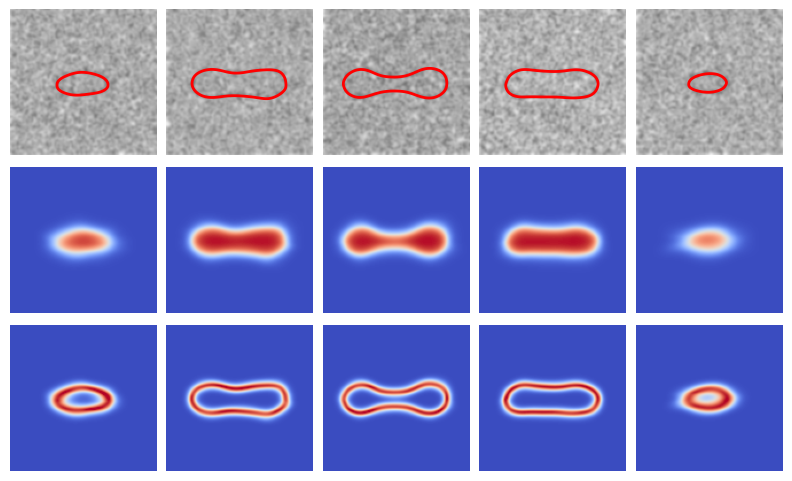

In [10]:
## FIGURE 2E (Phase Field Final Output)

import os
import numpy as np
import matplotlib.pyplot as plt
from flax.training import checkpoints
from pinn.cryoet_io import load_mrc_data
from pinn.plot import visualize_cryoET_with_contours, visualize_phase

import mrcfile
import jax
import jax.numpy as jnp

# ==== Parameters =====
GRID_SIZE = 128
lambda_1 = 100000
lambda_2 = 1
lambda_3 = 100000
lambda_4 = 10
shape = "biconcave"
step = 10000
epsilon = 0.05
phase = 1

if phase == 0:
    _lambda_2 = 0
    _lambda_4 = 0
elif phase == 1:
    _lambda_2 = lambda_2
    _lambda_4 = 0
elif phase == 2:
    _lambda_2 = lambda_2
    _lambda_4 = lambda_4

extend_xy = None

additive = 0.1
missing  = 0.7
str_add = f"{additive:.2f}".replace('.', '')
str_miss = f"{missing:.1f}".replace('.', '')
slice_index_list = [24, 44, 64, 84, 104] 
axis = "z"

# ==== Load checkpoint data =====
checkpoint_dir = f"../outputs/logs/{shape}/data_0321/a{str_add}_m{str_miss}_g{GRID_SIZE}/phase{phase}_{lambda_1}_{_lambda_2}_{lambda_3}_{_lambda_4}/checkpoint_{step}"
checkpoint_path = os.path.abspath(checkpoint_dir)
print(checkpoint_path)
checkpoint_data = checkpoints.restore_checkpoint(ckpt_dir=checkpoint_path, target=None)

# ==== Load CryoET data =====
mrc_file_path = f"../data/synthetic/mrc/{shape}_a{str_add}_m{str_miss}.mrc"
cryoET_data = load_mrc_data(mrc_file_path, grid_size=GRID_SIZE)

n_col = len(slice_index_list)
n_row = 3
fig = plt.figure(figsize=(2*n_col, 2*n_row))

fig.subplots_adjust(
    wspace=0.05,   # width space (fraction of axes)
    hspace=0.08,   # height space
)

plt.style.reload_library()
with plt.style.context(["base", "transparent"]):

    # Row 1: target with contour
    for i, slice_index in enumerate(slice_index_list):
        ax = fig.add_subplot(n_row, n_col, i+1)
        visualize_cryoET_with_contours(ax, step, checkpoint_data, cryoET_data, no_label = True,
                                       grid_size=GRID_SIZE, slice_index=slice_index, axis=axis, thresholding=False, expand_xy=extend_xy)

    # Row 2: phi
    for i, slice_index in enumerate(slice_index_list):
        ax = fig.add_subplot(n_row, n_col, 1*n_col+i+1)
        visualize_phase(ax, epsilon=epsilon, checkpoint=checkpoint_data, component="phi",
                        grid_size=GRID_SIZE, slice_index=slice_index, axis=axis, no_label=True, vmin=-1, vmax=1, expand_xy=extend_xy)

    # Row 3: edge
    for i, slice_index in enumerate(slice_index_list):

        ax = fig.add_subplot(n_row, n_col, 2*n_col+i+1)
        visualize_phase(ax, epsilon=epsilon, checkpoint=checkpoint_data, component="tension", 
                        grid_size=GRID_SIZE, slice_index=slice_index, axis=axis, no_label=True, vmin=0.0, vmax=1.0, expand_xy=extend_xy)


    save_path = f"../outputs/figs/v_0321/synth/{shape}_a{str_add}_m{str_miss}_g{GRID_SIZE}"
    os.makedirs(save_path, exist_ok=True)
    plt.savefig(f"{save_path}/phase{phase}_{lambda_1}_{_lambda_2}_{lambda_3}_{_lambda_4}.png", bbox_inches="tight")
    plt.show()


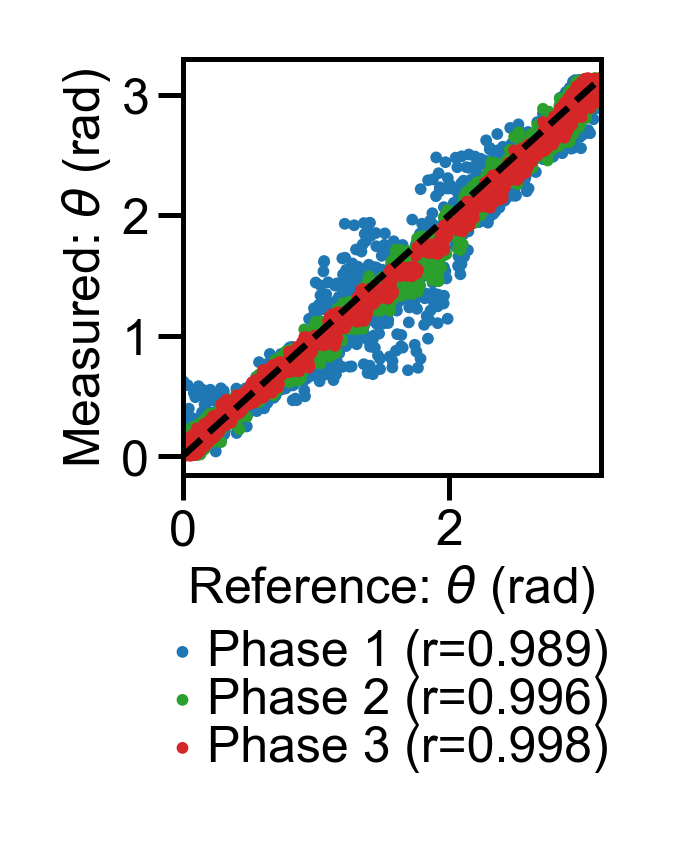

In [20]:
# FIGURE 2G (Quantification of Normal and Curvatures)

from pinn.normal_curves import load_mesh_npz, match_and_plot_multi_data
import matplotlib.pyplot as plt
import numpy as np
import os

# ==== Parameters =====
lambda_1 = 100000
lambda_2 = 1
lambda_3 = 100000
lambda_4 = 10
shape = "biconcave"
step = 10000
additive = 0.1
missing  = 0.7
grid_size = 128
str_add = f"{additive:.2f}".replace('.', '')
str_miss = f"{missing:.1f}".replace('.', '')
version  = "data_0321"
phase_list = [0, 1, 2]
figsize=(0.9, 0.9)
# figsize=(0.6, 0.9)
quantity = "theta"

save_path = f"../outputs/figs/v_0321/synth/{shape}_a{str_add}_m{str_miss}_g{grid_size}"
os.makedirs(save_path, exist_ok=True)

# ==== Load npz data =====
# GROUND TRUTH
npz_path = f"../data/synthetic/gt/relaxed_{shape}.npz"
verts_gt, faces_gt, norms_gt, theta_gt, curvs_gt, gauss_gt, force_gt = load_mesh_npz(npz_path)
force_gt = np.linalg.norm(force_gt, axis=1)

# PINN RESULTS
verts_pf = {}; theta_pf = {}; curvs_pf = {}; gauss_pf = {}; force_pf = {}
for phase in phase_list:
    if phase == 0:
        _lambda_2 = 0
        _lambda_4 = 0
    elif phase == 1:
        _lambda_2 = lambda_2
        _lambda_4 = 0
    elif phase == 2:
        _lambda_2 = lambda_2
        _lambda_4 = lambda_4
    checkpoint_dir = f"../outputs/logs/{shape}/{version}/a{str_add}_m{str_miss}_g{grid_size}"
    npz_path = f"{checkpoint_dir}/phase{phase}_{lambda_1}_{_lambda_2}_{lambda_3}_{_lambda_4}/verts_{step}.npz"
    verts, faces, norms, theta, curvs, gauss, force = load_mesh_npz(npz_path)
    force = np.linalg.norm(force, axis=1)
    verts_pf[phase] = verts; theta_pf[phase] = theta; curvs_pf[phase] = curvs; gauss_pf[phase] = gauss; force_pf[phase] = force


plt.style.reload_library()
with plt.style.context(["base", "transparent"]):

    if quantity == "theta":
        fig, _ = match_and_plot_multi_data(
                                verts_gt, theta_gt, 
                                B_datasets=[
                                    (verts_pf[0], theta_pf[0]),
                                    (verts_pf[1], theta_pf[1]),
                                    (verts_pf[2], theta_pf[2]),
                                ],
                                # xlabel="Angle: GT  (rad)",
                                # ylabel="Angle: PINN  (rad)",  
                                xlabel=r"Reference: $\theta$ (rad)",
                                ylabel=r"Measured: $\theta$ (rad)",
                                labels=["Phase 1", "Phase 2", "Phase 3"],
                                colors=["tab:blue", "tab:green", "tab:red"],
                                figsize=figsize,
                                xlim=(0, np.max(theta_gt)),
                               )
    elif quantity == "curvs":
        fig, _ = match_and_plot_multi_data(
                                verts_gt, curvs_gt, 
                                B_datasets=[
                                    (verts_pf[0], curvs_pf[0]),
                                    (verts_pf[1], curvs_pf[1]),
                                    (verts_pf[2], curvs_pf[2]),
                                ],
                                # xlabel=r"$H$: GT  (1/$\sigma$)",
                                # ylabel=r"$H$: PINN  (1/$\sigma$)",
                                xlabel=r"Reference: $H$ (1/$\sigma$)",
                                ylabel=r"Measured: $H$ (1/$\sigma$)",
                                labels=["Phase 1", "Phase 2", "Phase 3"],
                                colors=["tab:blue", "tab:green", "tab:red"],
                                figsize=figsize,
                                xlim=(np.min(curvs_gt), np.max(curvs_gt)),
                               )    
    elif quantity == "gauss":
        fig, _ = match_and_plot_multi_data(
                                verts_gt, gauss_gt, 
                                B_datasets=[
                                    (verts_pf[0], gauss_pf[0]),
                                    (verts_pf[1], gauss_pf[1]),
                                    (verts_pf[2], gauss_pf[2]),
                                ],
                                # xlabel=r"$G$: GT  (1/$\sigma$)",
                                # ylabel=r"$G$: PINN  (1/$\sigma$)",
                                xlabel=r"Reference: $G$ (1/$\sigma$)",
                                ylabel=r"Measured: $G$ (1/$\sigma$)",
                                labels=["Phase 1", "Phase 2", "Phase 3"],
                                colors=["tab:blue", "tab:green", "tab:red"],
                                figsize=figsize,
                                xlim=(np.min(gauss_gt), np.max(gauss_gt)),
                               )
    elif quantity == "force":
        fig, _ = match_and_plot_multi_data(
                                verts_gt, force_gt, 
                                B_datasets=[
                                    (verts_pf[0], force_pf[0]),
                                    (verts_pf[1], force_pf[1]),
                                    (verts_pf[2], force_pf[2]),
                                ],
                                xlabel=r"Force: GT  ()",
                                ylabel=r"Force: PINN  ()",
                                labels=["Phase 1", "Phase 2", "Phase 3"],
                                colors=["tab:blue", "tab:green", "tab:red"],
                                figsize=figsize,
                                xlim=(np.min(force_gt), np.max(force_gt)),
                               )
    
    fig.savefig(f"{save_path}/cor_{quantity}_l{lambda_1}-{lambda_2}-{lambda_3}-{lambda_4}.pdf", bbox_inches="tight")
    plt.show()

In [6]:
## FIGURE 3C (measurement vs stages: bar plot)

import os
import numpy as np
import matplotlib.pyplot as plt
from flax.training import checkpoints
from pinn.analysis import surface_dice
from pinn.normal_curves import match_nearest_neighbor, load_mesh_npz, plot_stage_bars
from matplotlib.ticker import MaxNLocator

# ==== Parameters =====
lambda_1 = 100000
lambda_2 = 1
lambda_3 = 100000
lambda_4 = 10
shape_list = ["biconcave", "bud_04"]
additive = 0.1
missing = 0.7
version  = "data_0321"
GRID_SIZE = 128
grid_size = 128
step = 10000
phase_list = [0,1,2]

# ============================================================
# Input datasets
# ============================================================

dice = {}; theta_cor = {}; curvs_cor = {}; gauss_cor = {}

for shape in shape_list:
    mrc_path = f"../data/synthetic/mrc/{shape}_a000_m00.mrc"
    npz_path = f"../data/synthetic/gt/relaxed_{shape}.npz"
    verts_gt, _, _, theta_gt, curvs_gt, gauss_gt, _ = load_mesh_npz(npz_path)
    dice[shape] = {}; theta_cor[shape] = {}; curvs_cor[shape] = {}; gauss_cor[shape] = {}
    
    for phase in phase_list:
        if phase == 0:
            _lambda_2 = 0
            _lambda_4 = 0
        elif phase == 1:
            _lambda_2 = lambda_2
            _lambda_4 = 0
        elif phase == 2:
            _lambda_2 = lambda_2
            _lambda_4 = lambda_4
        
        str_add = f"{additive:.2f}".replace('.', '')
        str_miss = f"{missing:.1f}".replace('.', '')
        
        root_dir = f"../outputs/logs/{shape}/{version}/a{str_add}_m{str_miss}_g{grid_size}"        
        data_dir = os.path.abspath(f"{root_dir}/phase{phase}_{lambda_1}_{_lambda_2}_{lambda_3}_{_lambda_4}")
        ckpt_dir = os.path.join(data_dir, f"checkpoint_{step}")
        ckpt_dat = checkpoints.restore_checkpoint(ckpt_dir=ckpt_dir, target=None)
        print(data_dir)

        npz_path = f"{data_dir}/verts_{step}.npz"

        if not os.path.exists(npz_path):
            continue  # skip

        dice[shape][phase] = surface_dice(mrc_path, ckpt_dat, grid_size=GRID_SIZE, threshold=0.6, band_thickness=0.4)    
        verts, _, _, theta, curvs, gauss, _ = load_mesh_npz(npz_path)
        theta_cor[shape][phase] = match_nearest_neighbor(verts_gt, theta_gt, verts, theta)
        curvs_cor[shape][phase] = match_nearest_neighbor(verts_gt, curvs_gt, verts, curvs)
        gauss_cor[shape][phase] = match_nearest_neighbor(verts_gt, gauss_gt, verts, gauss)


# ============================================================
# Generate the four plots
# ============================================================
save_path = f"../outputs/figs/v_0321/synth"

plt.style.reload_library()
with plt.style.context(["base", "transparent"]):
    
    fig_dice, ax_dice = plot_stage_bars(dice)
    fig_theta, ax_theta = plot_stage_bars(theta_cor)    
    fig_curvs, ax_curvs = plot_stage_bars(curvs_cor)
    fig_gauss, ax_gauss = plot_stage_bars(gauss_cor)
    
    fig_dice.savefig(f"{save_path}/bar_dice.pdf", dpi=300, bbox_inches="tight")
    fig_theta.savefig(f"{save_path}/bar_theta.pdf", dpi=300, bbox_inches="tight")    
    fig_curvs.savefig(f"{save_path}/bar_curvs.pdf", dpi=300, bbox_inches="tight")
    fig_gauss.savefig(f"{save_path}/bar_gauss.pdf", dpi=300, bbox_inches="tight")        

/mmfs1/gscratch/matsulab/sim/pinn-exploration-model/outputs/logs/biconcave/data_0321/a010_m07_g128/phase0_100000_0_100000_0
/mmfs1/gscratch/matsulab/sim/pinn-exploration-model/outputs/logs/biconcave/data_0321/a010_m07_g128/phase1_100000_1_100000_0
/mmfs1/gscratch/matsulab/sim/pinn-exploration-model/outputs/logs/biconcave/data_0321/a010_m07_g128/phase2_100000_1_100000_10
/mmfs1/gscratch/matsulab/sim/pinn-exploration-model/outputs/logs/bud_04/data_0321/a010_m07_g128/phase0_100000_0_100000_0
/mmfs1/gscratch/matsulab/sim/pinn-exploration-model/outputs/logs/bud_04/data_0321/a010_m07_g128/phase1_100000_1_100000_0
/mmfs1/gscratch/matsulab/sim/pinn-exploration-model/outputs/logs/bud_04/data_0321/a010_m07_g128/phase2_100000_1_100000_10


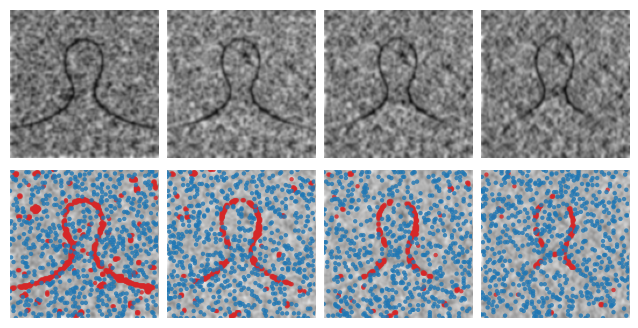

In [22]:
## FIGURE 3A (Input Images, Comparison of Noise)

import os
import numpy as np
import matplotlib.pyplot as plt
from pinn.cryoet_io import load_mrc_data
from data_generation.preprocess import overlay_points_on_cryoet_ax
from pinn.utils import load_pts_data

import mrcfile
import jax
import jax.numpy as jnp

# ==== Parameters =====
GRID_SIZE = 128
shape = "bud_04"
additive = 0.1
# missing_list  = [0.0, 0.6, 0.7, 0.8]
missing = 0.4
axis = "z"
grid_size = 128
# grid_size_list = [128, 64, 32, 16]
# grid_size_z_list = [128, 64, 32, 16]
wedge_list = [90, 80, 70, 60]
pts_size = 10
lambda_1 = 100000
lambda_2 = 1
lambda_3 = 100000

# n_col = len(missing_list)
# n_col = len(grid_size_z_list)
n_col = len(wedge_list)
n_row = 2
fig = plt.figure(figsize=(2*n_col, 2*n_row))

fig.subplots_adjust(
    wspace=0.05,   # width space (fraction of axes)
    hspace=0.08,   # height space
)

plt.style.reload_library()
with plt.style.context(["base", "transparent"]):

    # for i, missing in enumerate(missing_list):
    # for i, grid_size in enumerate(grid_size_list):
    # for i, grid_size_z in enumerate(grid_size_z_list):
    for i, wedge in enumerate(wedge_list):
        
        if missing == 0.0:
            _additive = 0.0
        else:
            _additive = additive
        str_add  = f"{_additive:.2f}".replace('.', '')
        str_miss = f"{missing:.1f}".replace('.', '')

        # ==== Load point data =====
        pts_path = f"../data/synthetic/pts"
        # edge = load_pts_data(f"{pts_path}/edge/e_{shape}_a{str_add}_m{str_miss}_g{grid_size}.npz", perm=(0,1,2))
        # if grid_size_z == 128:
        #     edge = load_pts_data(f"{pts_path}/edge/e_{shape}_a{str_add}_m{str_miss}_g{grid_size}.npz", perm=(0,1,2))
        # else:
        #     edge = load_pts_data(f"{pts_path}/edge/e_{shape}_a{str_add}_m{str_miss}_g{grid_size}_gz{grid_size_z}.npz", perm=(0,1,2))
        if wedge == 90:
            edge = load_pts_data(f"{pts_path}/edge/e_{shape}_a{str_add}_m{str_miss}_g{grid_size}.npz", perm=(0,1,2))
        else:
            edge = load_pts_data(f"{pts_path}/edge/e_{shape}_a{str_add}_m{str_miss}_wz{wedge}.npz", perm=(0,1,2))

        pt_e = edge["points"][edge["label"] == 1][:, [2, 0, 1]]
        pt_b = edge["points"][edge["label"] == 0][:, [2, 0, 1]]
        overlay_edge = [
            {"data": pt_e, "label": "Edge", "color": "tab:red"},
            {"data": pt_b, "label": "Bulk", "color": "tab:blue"},
        ]
        
        # ==== Load CryoET data =====
        # mrc_file_path = f"../data/synthetic/mrc/{shape}_a{str_add}_m{str_miss}.mrc"
        if wedge == 90:
            mrc_file_path = f"../data/synthetic/mrc/{shape}_a{str_add}_m{str_miss}.mrc"            
        else:
            mrc_file_path = f"../data/synthetic/mrc/{shape}_a{str_add}_m{str_miss}_wz{wedge}.mrc"
        cryoET_data = load_mrc_data(mrc_file_path, grid_size=grid_size)
        # cryoET_data = load_mrc_data(mrc_file_path, grid_size=(grid_size_z, grid_size, grid_size))
        
        ax = fig.add_subplot(2, n_col, i+1)
        overlay_points_on_cryoet_ax(ax, cryoet=cryoET_data, axis=axis, slice_index=grid_size//2)

        ax = fig.add_subplot(2, n_col, 1*n_col+i+1)
        overlay_points_on_cryoet_ax(ax, cryoet=cryoET_data, overlays=overlay_edge, axis=axis, slice_index=grid_size//2, pts_size=pts_size, cryo_alpha=0.6)
    
    # plt.savefig(f"../outputs/figs/v_0321/synth/noise-additive/input-{shape}.png", bbox_inches="tight")
    # plt.savefig(f"../outputs/figs/v_0321/synth/noise-sparse/input-{shape}.png", bbox_inches="tight")
    # plt.savefig(f"../outputs/figs/v_0321/synth/noise-aniso/input-{shape}-noisy.png", bbox_inches="tight")
    plt.savefig(f"../outputs/figs/v_0321/synth/noise-wedge/input-{shape}-noisy.png", bbox_inches="tight")    
    plt.show()

In [7]:
## FIGURE 3C (Noise vs Metric)
## Load data

import os
import numpy as np
import matplotlib.pyplot as plt
from flax.training import checkpoints
from pinn.analysis import surface_dice
from pinn.normal_curves import match_nearest_neighbor, load_mesh_npz

# ==== Parameters =====
lambda_1 = 100000
lambda_2 = 1
lambda_3 = 100000
lambda_4 = 10
shape_list = ["biconcave", "bud_04"]
# missing_list  = [0.0, 0.6, 0.7, 0.8]
additive = 0.1
missing = 0.4
version  = "data_0321"
GRID_SIZE = 128
grid_size = 128
# grid_size_list = [128, 64, 32, 16]
# grid_size_z_list = [128, 64, 32, 16]
wedge_list = [90, 80, 70, 60]
step = 10000
phase_list = [0,1,2]


dice = {}; theta_cor = {}; curvs_cor = {}; gauss_cor = {}

for shape in shape_list:
    mrc_path = f"../data/synthetic/mrc/{shape}_a000_m00.mrc"
    npz_path = f"../data/synthetic/gt/relaxed_{shape}.npz"
    verts_gt, _, _, theta_gt, curvs_gt, gauss_gt, _ = load_mesh_npz(npz_path)
    dice[shape] = {}; theta_cor[shape] = {}; curvs_cor[shape] = {}; gauss_cor[shape] = {}
    
    for phase in phase_list:
        dice[shape][phase] = {}; theta_cor[shape][phase] = {}; curvs_cor[shape][phase] = {}; gauss_cor[shape][phase] = {}
        if phase == 0:
            _lambda_2 = 0
            _lambda_4 = 0
        elif phase == 1:
            _lambda_2 = lambda_2
            _lambda_4 = 0
        elif phase == 2:
            _lambda_2 = lambda_2
            _lambda_4 = lambda_4
        
        # for missing in missing_list:
        # for grid_size in grid_size_list:
        # for grid_size_z in grid_size_z_list:
        for wedge in wedge_list:

            # label = missing
            # label = grid_size
            # label = grid_size_z
            label = wedge

            if missing == 0.0:
                _additive = 0.00
            else:
                _additive = additive
    
            str_add = f"{_additive:.2f}".replace('.', '')
            str_miss = f"{missing:.1f}".replace('.', '')
            
            # root_dir = f"../outputs/logs/{shape}/{version}/a{str_add}_m{str_miss}_g{grid_size}"
            # if grid_size_z == 128:
            #     root_dir = f"../outputs/logs/{shape}/{version}/a{str_add}_m{str_miss}_g{grid_size}"
            # else:
            #     root_dir = f"../outputs/logs/{shape}/{version}/a{str_add}_m{str_miss}_g{grid_size}_gz{grid_size_z}"

            if wedge == 90:
                root_dir = f"../outputs/logs/{shape}/{version}/a{str_add}_m{str_miss}_g{grid_size}"
            else:
                root_dir = f"../outputs/logs/{shape}/{version}/a{str_add}_m{str_miss}_wz{wedge}"
            
            data_dir = os.path.abspath(f"{root_dir}/phase{phase}_{lambda_1}_{_lambda_2}_{lambda_3}_{_lambda_4}")
            ckpt_dir = os.path.join(data_dir, f"checkpoint_{step}")
            ckpt_dat = checkpoints.restore_checkpoint(ckpt_dir=ckpt_dir, target=None)
            print(data_dir)

            npz_path = f"{data_dir}/verts_{step}.npz"

            if not os.path.exists(npz_path):
                continue  # skip

            dice[shape][phase][label] = surface_dice(mrc_path, ckpt_dat, grid_size=GRID_SIZE, threshold=0.6, band_thickness=0.4)    
            verts, _, _, theta, curvs, gauss, _ = load_mesh_npz(npz_path)
            theta_cor[shape][phase][label] = match_nearest_neighbor(verts_gt, theta_gt, verts, theta)
            curvs_cor[shape][phase][label] = match_nearest_neighbor(verts_gt, curvs_gt, verts, curvs)
            gauss_cor[shape][phase][label] = match_nearest_neighbor(verts_gt, gauss_gt, verts, gauss)


/mmfs1/gscratch/matsulab/sim/pinn-exploration-model/outputs/logs/biconcave/data_0321/a010_m04_g128/phase0_100000_0_100000_0
/mmfs1/gscratch/matsulab/sim/pinn-exploration-model/outputs/logs/biconcave/data_0321/a010_m04_wz80/phase0_100000_0_100000_0
/mmfs1/gscratch/matsulab/sim/pinn-exploration-model/outputs/logs/biconcave/data_0321/a010_m04_wz70/phase0_100000_0_100000_0
/mmfs1/gscratch/matsulab/sim/pinn-exploration-model/outputs/logs/biconcave/data_0321/a010_m04_wz60/phase0_100000_0_100000_0
/mmfs1/gscratch/matsulab/sim/pinn-exploration-model/outputs/logs/biconcave/data_0321/a010_m04_g128/phase1_100000_1_100000_0
/mmfs1/gscratch/matsulab/sim/pinn-exploration-model/outputs/logs/biconcave/data_0321/a010_m04_wz80/phase1_100000_1_100000_0
/mmfs1/gscratch/matsulab/sim/pinn-exploration-model/outputs/logs/biconcave/data_0321/a010_m04_wz70/phase1_100000_1_100000_0
/mmfs1/gscratch/matsulab/sim/pinn-exploration-model/outputs/logs/biconcave/data_0321/a010_m04_wz60/phase1_100000_1_100000_0
/mmfs1/g

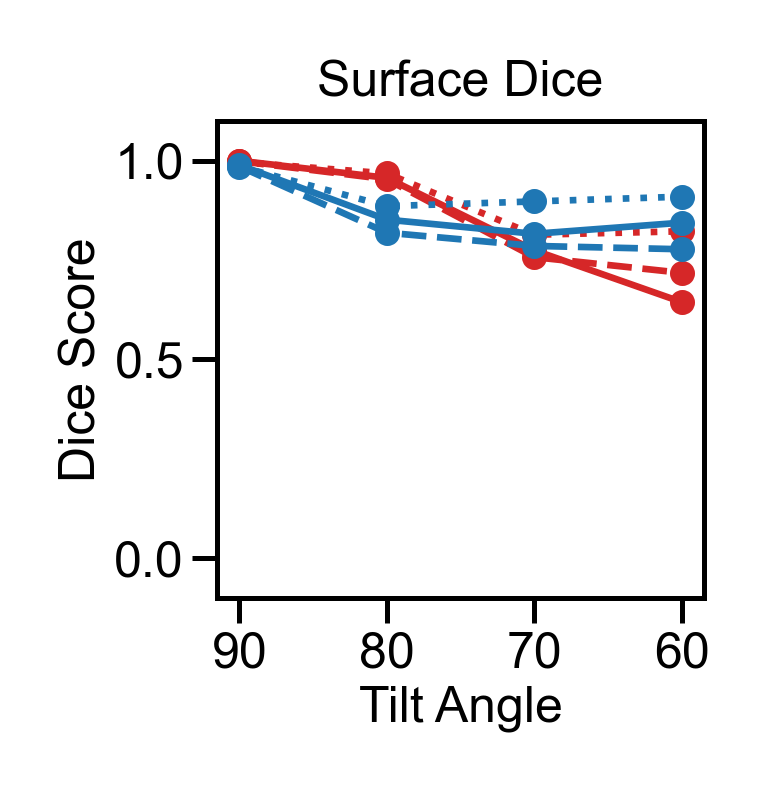

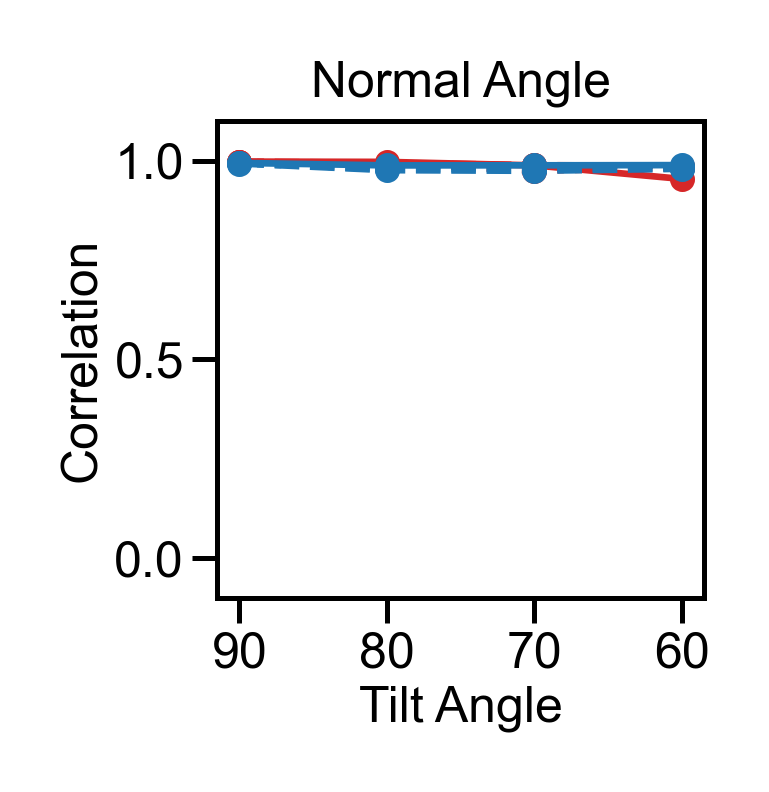

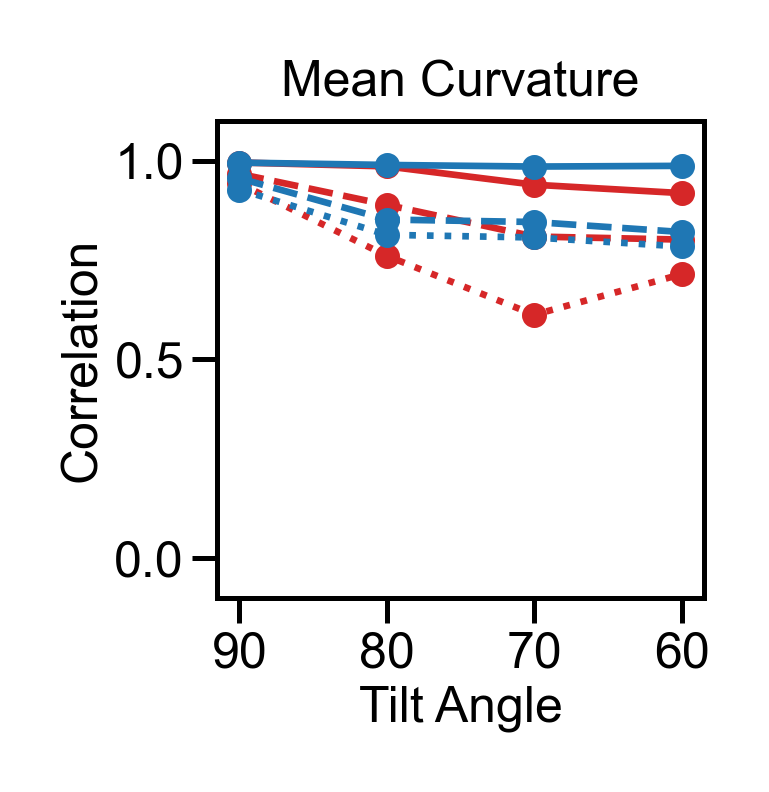

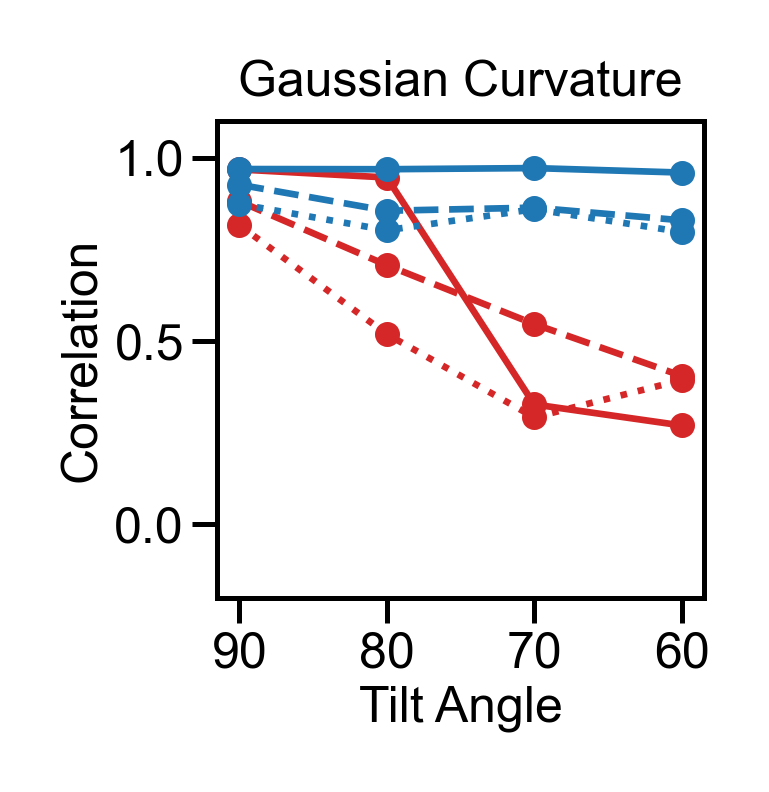

In [8]:
from pinn.normal_curves import plot_ablation

figsize = (1.3,1.3)

# save_path = "../outputs/figs/v_0321/synth/noise-additive"
# xtick_labels=None
# xlabel="Noise Level"
# x_values=missing_list

# save_path = "../outputs/figs/v_0321/synth/noise-sparse"
# xtick_labels=["1/128", "1/64", "1/32", "1/16"]
# xlabel="Resolution"
# x_values=grid_size_list

# save_path = "../outputs/figs/v_0321/synth/noise-aniso"
# xtick_labels=["1", "2", "4", "8"]
# xlabel="Anisotropy"
# x_values=grid_size_z_list

save_path = "../outputs/figs/v_0321/synth/noise-wedge"
xtick_labels=["90", "80", "70", "60"]
xlabel="Tilt Angle"
x_values=wedge_list

plt.style.reload_library()
with plt.style.context(["base", "transparent"]):

    plot_ablation(
        dice,
        shape_list=shape_list,
        phase_list=phase_list,
        x_values=x_values,
        xlabel=xlabel,
        ylabel="Dice Score",
        title="Surface Dice",
        figsize=figsize,
        show_legend=False,
        ylim=(-0.1,1.1),
        # gap_after_first=True,
        xtick_labels=xtick_labels,
        save_path=f"{save_path}/dice.pdf",
        # save_path=f"{save_path}/legend.pdf"
    )
    
    plot_ablation(
        theta_cor,
        shape_list=shape_list,
        phase_list=phase_list,
        x_values=x_values,
        xlabel=xlabel,
        ylabel="Correlation",
        title="Normal Angle",
        figsize=figsize,
        show_legend=False,
        ylim=(-0.1,1.1),
        # gap_after_first=True,
        xtick_labels=xtick_labels,
        save_path=f"{save_path}/theta.pdf",
    )
    
    plot_ablation(
        curvs_cor,
        shape_list=shape_list,
        phase_list=phase_list,
        x_values=x_values,
        xlabel=xlabel,
        ylabel="Correlation",
        title="Mean Curvature",
        figsize=figsize,
        show_legend=False,
        ylim=(-0.1,1.1),
        # gap_after_first=True,  
        xtick_labels=xtick_labels,
        save_path=f"{save_path}/curvs.pdf"
    )
        
    plot_ablation(
        gauss_cor,
        shape_list=shape_list,
        phase_list=phase_list,
        x_values=x_values,
        xlabel=xlabel,
        ylabel="Correlation",
        title="Gaussian Curvature",
        figsize=figsize,
        show_legend=False,
        # ylim=(-0.1,1.1),
        ylim=(-0.2,1.1),
        # gap_after_first=True,
        xtick_labels=xtick_labels,
        save_path=f"{save_path}/gauss.pdf"
    )

In [4]:
dice

{'biconcave': {0: {}, 1: {}, 2: {}}, 'bud_04': {0: {}, 1: {}, 2: {}}}

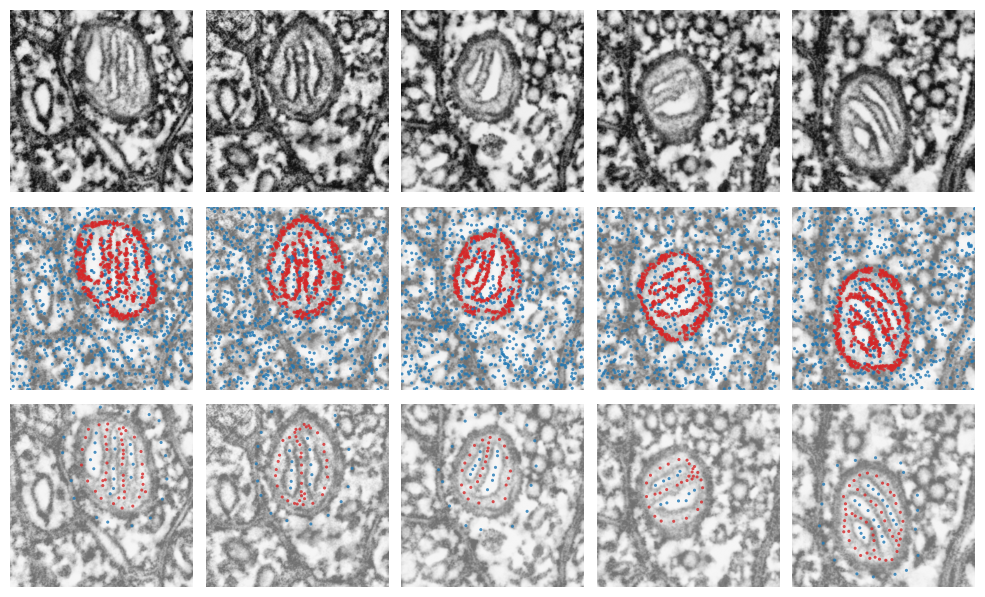

In [11]:
## FIGURE 5A (Exprimental Input Images)

import os
import numpy as np
import matplotlib.pyplot as plt
from pinn.cryoet_io import load_mrc_data
from data_generation.preprocess import overlay_points_on_cryoet_ax
from pinn.utils import load_pts_data
from pinn.plot import show_cryoet_slice

import mrcfile
import jax
import jax.numpy as jnp

# # ==== Parameters for Golgi =====
# GRID_SIZE = 128
# data_id = "czii_27042022"
# shape = "golgi_01"
# slice_index_list = range(40, 81, 10)

# ==== Parameters for Mito =====
GRID_SIZE = 360
data_id = "mendelsohn_2021"
shape = "mito_01"
slice_index_list = range(100, 301, 50)
expand_xy = 282/360

hidden_dim=128
axis = "x"
pts_size=5

# ==== Load point data =====
pts_path = f"../data/experimental/pts"
edge = load_pts_data(f"{pts_path}/edge/{data_id}/pt_e_{shape}.npz", perm=(2,1,0))
sign = load_pts_data(f"{pts_path}/sign/{data_id}/pt_s_{shape}.npz", perm=(2,1,0))

# ==== Load CryoET data =====
if shape == "golgi_01":
    mrc_file_path = f"../data/experimental/vol/formatted/{data_id}/{shape}.mrc"
elif shape == "mito_01":
    mrc_file_path = f"../data/experimental/vol/raw/{data_id}/{shape}.mrc"
cryoET_data = load_mrc_data(mrc_file_path, grid_size=GRID_SIZE)

n_col = len(slice_index_list)
n_row = 3
fig = plt.figure(figsize=(2.5*n_col, 2.5*n_row))

fig.subplots_adjust(
    wspace=0.05,   # width space (fraction of axes)
    hspace=0.08,   # height space
)

plt.style.reload_library()
with plt.style.context(["base", "transparent"]):

    # Row 1: 
    for i, slice in enumerate(slice_index_list):
        ax = fig.add_subplot(n_row, n_col, i+1)
        overlay_points_on_cryoet_ax(ax, cryoet=cryoET_data, axis=axis, slice_index=slice)
        # ax.invert_yaxis()

    # Row 2:
    for i, slice in enumerate(slice_index_list):
        ax = fig.add_subplot(n_row, n_col, 1*n_col+i+1)
        pt_e = edge["points"][edge["label"] == 1]
        pt_b = edge["points"][edge["label"] == 0]
        overlays = [
            {"data": pt_e, "label": "Edge", "color": "tab:red"},
            {"data": pt_b, "label": "Bulk", "color": "tab:blue"},
        ]
        overlay_points_on_cryoet_ax(ax, cryoet=cryoET_data, overlays=overlays, axis=axis, slice_index=slice, 
                                    pts_size=pts_size, cryo_alpha=0.6, expand_xy=expand_xy)
        # ax.invert_yaxis()

    # Row 3:
    for i, slice in enumerate(slice_index_list):
        ax = fig.add_subplot(n_row, n_col, 2*n_col+i+1)
        pt_p = sign["points"][sign["label"] ==  1]
        pt_n = sign["points"][sign["label"] == -1]
        overlays = [
            {"data": pt_p, "label": "Phi = +1", "color": "tab:red"},
            {"data": pt_n, "label": "Phi = -1", "color": "tab:blue"},
        ]
        overlay_points_on_cryoet_ax(ax, cryoet=cryoET_data, overlays=overlays, axis=axis, slice_index=slice, 
                                    pts_size=pts_size, cryo_alpha=0.6, expand_xy=expand_xy)
        # ax.invert_yaxis()

    save_path = f"../outputs/figs/v_0321/experiment/{data_id}"
    os.makedirs(save_path, exist_ok=True)
    plt.savefig(f"{save_path}/input-{shape}-{hidden_dim}.png", bbox_inches="tight")
    plt.show()

/mmfs1/gscratch/matsulab/sim/pinn-exploration-model/outputs/logs/mendelsohn_2021/mito_01_128/phase2_100000_1_100000_0.01/checkpoint_10000


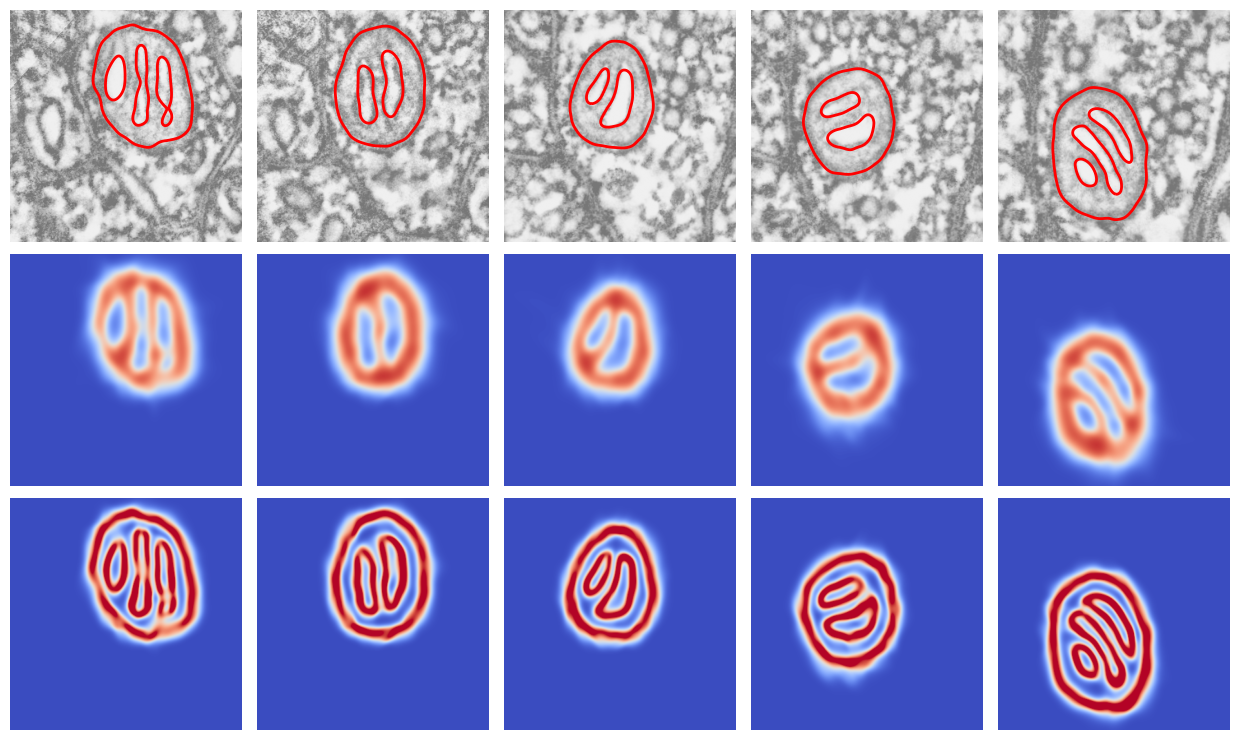

In [14]:
### FIGURE 5B (Output for Experimental Data)

from pinn.plot import visualize_cryoET_with_contours, visualize_phase
import mrcfile
import os
import numpy as np
import matplotlib.pyplot as plt
from flax.training import checkpoints

# ==== Parameters =====
lambda_1 = 100000
lambda_2 = 1
lambda_3 = 100000
lambda_4 = 0.01
step = 10000
hidden_dim = 128
phase = 2
axis = "x"

# ==== Parameters for Golgi =====
# data_id = "czii_27042022"
# shape = "golgi_01"
# slices = list(range(40, 81, 10))
# expand_xy = None

# ==== Parameters for Mito =====
data_id = "mendelsohn_2021"
shape = "mito_01"
slices = range(100, 301, 50)
expand_xy = 282/360


if phase == 0:
    _lambda_2 = 0
    _lambda_4 = 0
elif phase == 1:
    _lambda_2 = lambda_2
    _lambda_4 = 0
elif phase == 2:
    _lambda_2 = lambda_2
    _lambda_4 = lambda_4

# ==== Load checkpoint data =====
checkpoint_dir = f"../outputs/logs/{data_id}/{shape}_{hidden_dim}/phase{phase}_{lambda_1}_{_lambda_2}_{lambda_3}_{_lambda_4}"
checkpoint_path = os.path.abspath(f"{checkpoint_dir}/checkpoint_{step}")
checkpoint_data = checkpoints.restore_checkpoint(ckpt_dir=checkpoint_path, target=None)
print(checkpoint_path)

# ===== Load cryoET data =====
if shape == "golgi_01":
    mrc_file_path = f"../data/experimental/vol/formatted/{data_id}/{shape}.mrc"
elif shape == "mito_01":
    mrc_file_path = f"../data/experimental/vol/raw/{data_id}/{shape}.mrc"
with mrcfile.open(mrc_file_path, permissive=True) as mrc:
    cryoET_data = mrc.data
# cryoET_data = 1 - cryoET_data
grid_size = cryoET_data.shape[0]

# ==== Plot output =====
n = len(slices)
fig, axes = plt.subplots(3, n, figsize=(2.5*n, 2.5*3))

# --- row 1: cryoET + contour ---
for ax, slice_index in zip(axes[0], slices):
    visualize_cryoET_with_contours(
        ax, step, checkpoint_data, cryoET_data, grid_size=grid_size, 
        slice_index=slice_index, axis=axis, no_label=True, expand_xy=expand_xy, hidden_dim=hidden_dim,
    )
    # ax.invert_yaxis()

# --- row 2: phi ---
for ax, slice_index in zip(axes[1], slices):
    visualize_phase(
        ax, epsilon=0.05, checkpoint=checkpoint_data, component="phi", grid_size=grid_size,
        slice_index=slice_index, axis=axis, no_label=True, vmin=-1, vmax=1, expand_xy=expand_xy, hidden_dim=hidden_dim,
    )
    # ax.invert_yaxis()

# --- row 3: tension ---
for ax, slice_index in zip(axes[2], slices):
    visualize_phase(
        ax, epsilon=0.05, checkpoint=checkpoint_data, component="tension", grid_size=grid_size,
        slice_index=slice_index, axis=axis, no_label=True, vmin=0.0, vmax=1.0, expand_xy=expand_xy, hidden_dim=hidden_dim,
    )
    # ax.invert_yaxis()

plt.tight_layout()
plt.savefig(f"../outputs/figs/v_0321/experiment/{data_id}/output-{shape}-{hidden_dim}.png", bbox_inches="tight")
plt.show()



/mmfs1/gscratch/matsulab/sim/pinn-exploration-model/outputs/logs/mendelsohn_2021/mito_01_4/phase2_100000_1_100000_0.01/checkpoint_10000
/mmfs1/gscratch/matsulab/sim/pinn-exploration-model/outputs/logs/mendelsohn_2021/mito_01_8/phase2_100000_1_100000_0.01/checkpoint_10000
/mmfs1/gscratch/matsulab/sim/pinn-exploration-model/outputs/logs/mendelsohn_2021/mito_01_16/phase2_100000_1_100000_0.01/checkpoint_10000
/mmfs1/gscratch/matsulab/sim/pinn-exploration-model/outputs/logs/mendelsohn_2021/mito_01_32/phase2_100000_1_100000_0.01/checkpoint_10000
/mmfs1/gscratch/matsulab/sim/pinn-exploration-model/outputs/logs/mendelsohn_2021/mito_01_64/phase2_100000_1_100000_0.01/checkpoint_10000
/mmfs1/gscratch/matsulab/sim/pinn-exploration-model/outputs/logs/mendelsohn_2021/mito_01_128/phase2_100000_1_100000_0.01/checkpoint_10000


W0421 00:39:46.382327   72631 gemm_fusion_autotuner.cc:1053] Compiling 10 configs for 2 fusions on a single thread.
W0421 00:39:50.139170   72631 gemm_fusion_autotuner.cc:1053] Compiling 10 configs for 2 fusions on a single thread.
W0421 00:39:52.023129   72631 gemm_fusion_autotuner.cc:1053] Compiling 10 configs for 2 fusions on a single thread.
W0421 00:39:53.896145   72631 gemm_fusion_autotuner.cc:1053] Compiling 12 configs for 2 fusions on a single thread.
W0421 00:39:56.543385   72631 gemm_fusion_autotuner.cc:1053] Compiling 10 configs for 2 fusions on a single thread.
W0421 00:40:00.094627   72631 gemm_fusion_autotuner.cc:1053] Compiling 28 configs for 3 fusions on a single thread.
W0421 00:40:18.092404   72631 gemm_fusion_autotuner.cc:1050] Compiling 5 configs for gemm_fusion_dot_general.1 on a single thread.
W0421 00:40:19.101344   72631 gemm_fusion_autotuner.cc:1050] Compiling 5 configs for gemm_fusion_dot_general.1 on a single thread.
W0421 00:40:21.400334   72631 gemm_fusion_

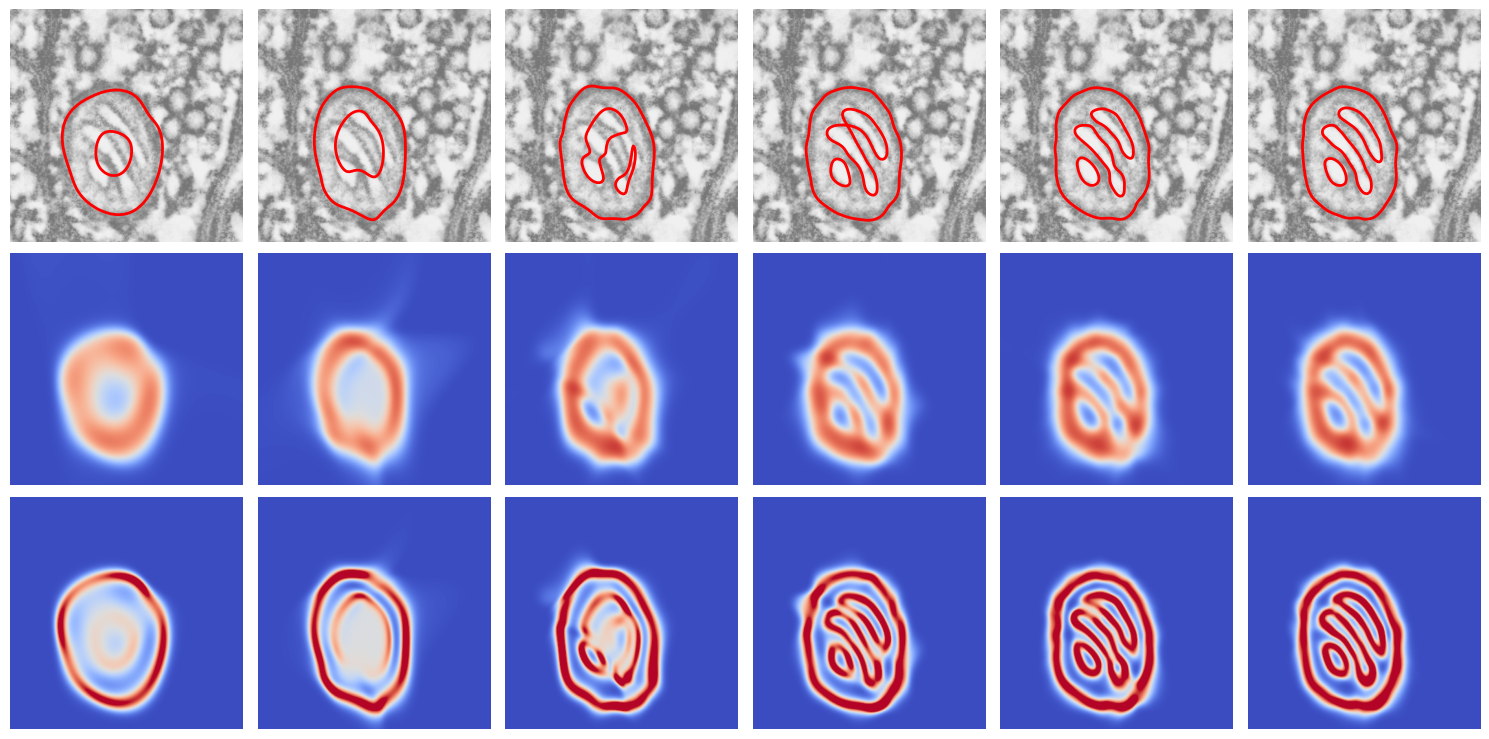

In [7]:
### FIGURE 6A (Comparison of hidden layer size)

from pinn.plot import visualize_cryoET_with_contours, visualize_phase
import mrcfile
import os
import numpy as np
import matplotlib.pyplot as plt
from flax.training import checkpoints

# ==== Parameters =====
lambda_1 = 100000
lambda_2 = 1
lambda_3 = 100000
step = 10000
hidden_dim = 128
phase = 2
axis = "x"
layers = [4, 8, 16, 32, 64, 128]

# ==== Parameters for Golgi =====
# data_id = "czii_27042022"
# shape = "golgi_01"
# expand_xy = None
# slice_index=50
# lambda_4 = 0.1

# ==== Parameters for Mito =====
data_id = "mendelsohn_2021"
shape = "mito_01"
expand_xy = 282/360
slice_index=300
lambda_4 = 0.01


if phase == 0:
    _lambda_2 = 0
    _lambda_4 = 0
elif phase == 1:
    _lambda_2 = lambda_2
    _lambda_4 = 0
elif phase == 2:
    _lambda_2 = lambda_2
    _lambda_4 = lambda_4

# ==== Load checkpoint data =====
checkpoint_list = {}
for hidden_dim in layers:
    checkpoint_dir = f"../outputs/logs/{data_id}/{shape}_{hidden_dim}/phase{phase}_{lambda_1}_{_lambda_2}_{lambda_3}_{_lambda_4}"
    checkpoint_path = os.path.abspath(f"{checkpoint_dir}/checkpoint_{step}")
    checkpoint_data = checkpoints.restore_checkpoint(ckpt_dir=checkpoint_path, target=None)
    checkpoint_list[hidden_dim] = checkpoint_data
    print(checkpoint_path)

# ===== Load cryoET data =====
if shape == "golgi_01":
    mrc_file_path = f"../data/experimental/vol/formatted/{data_id}/{shape}.mrc"
elif shape == "mito_01":
    mrc_file_path = f"../data/experimental/vol/raw/{data_id}/{shape}.mrc"
with mrcfile.open(mrc_file_path, permissive=True) as mrc:
    cryoET_data = mrc.data
grid_size = cryoET_data.shape[0]

# ==== Plot output =====
n = len(layers)
fig, axes = plt.subplots(3, n, figsize=(2.5*n, 2.5*3))

# --- row 1: cryoET + contour ---
for ax, hidden_dim in zip(axes[0], layers):
    visualize_cryoET_with_contours(
        ax, step, checkpoint_list[hidden_dim], cryoET_data, grid_size=grid_size, 
        slice_index=slice_index, axis=axis, no_label=True, expand_xy=expand_xy,hidden_dim=hidden_dim
    )
    # ax.invert_yaxis()

# --- row 2: phi ---
for ax, hidden_dim in zip(axes[1], layers):
    visualize_phase(
        ax, epsilon=0.05, checkpoint=checkpoint_list[hidden_dim], component="phi", grid_size=grid_size,
        slice_index=slice_index, axis=axis, no_label=True, vmin=-1, vmax=1, expand_xy=expand_xy,hidden_dim=hidden_dim
    )
    # ax.invert_yaxis()

# --- row 3: tension ---
for ax, hidden_dim in zip(axes[2], layers):
    visualize_phase(
        ax, epsilon=0.05, checkpoint=checkpoint_list[hidden_dim], component="tension", grid_size=grid_size,
        slice_index=slice_index, axis=axis, no_label=True, vmin=0.0, vmax=1.0, expand_xy=expand_xy,hidden_dim=hidden_dim
    )
    # ax.invert_yaxis()

plt.tight_layout()
plt.savefig(f"../outputs/figs/v_0321/experiment/{data_id}/scaling-{shape}.png", bbox_inches="tight")
plt.show()

/mmfs1/gscratch/matsulab/sim/pinn-exploration-model/outputs/logs/jrc_cos7-1b/unscaled/bud-11/phase2_100000_1_100000_10/checkpoint_10000


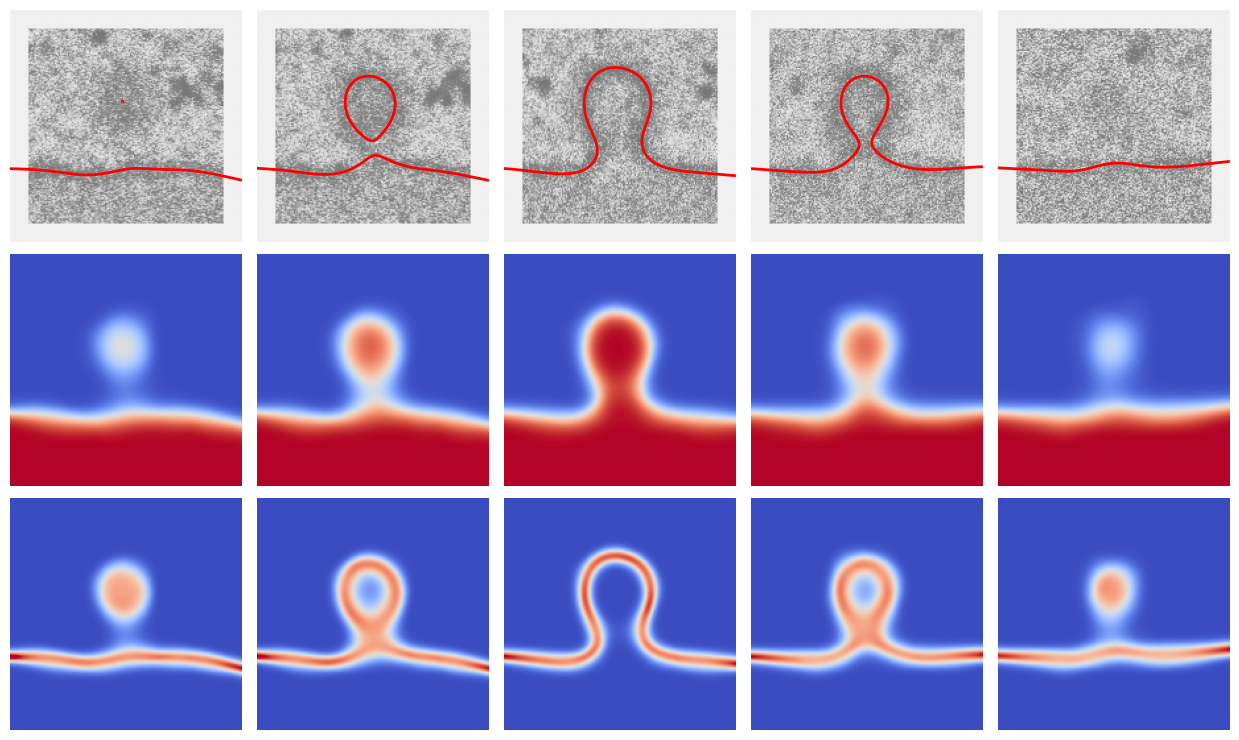

In [11]:
### FIGURE 7B (Output for CME Data)

from pinn.plot import visualize_cryoET_with_contours, visualize_phase
import tifffile as tiff
import os
import numpy as np
import matplotlib.pyplot as plt
from flax.training import checkpoints

# ==== Parameters =====
lambda_1 = 100000
lambda_2 = 1
lambda_3 = 100000
lambda_4 = 10
step = 10000
hidden_dim = 128
phase = 2
axis = "x"


# ==== Parameters for Mito =====
data_id = "jrc_cos7-1b"
shape = "bud-11"
# slices = list(range(60, 110, 8))
slices = [60, 68, 84, 100, 108]
expand_xy = None


if phase == 0:
    _lambda_2 = 0
    _lambda_4 = 0
elif phase == 1:
    _lambda_2 = lambda_2
    _lambda_4 = 0
elif phase == 2:
    _lambda_2 = lambda_2
    _lambda_4 = lambda_4

# ==== Load checkpoint data =====
checkpoint_dir = f"../outputs/logs/{data_id}/unscaled/{shape}/phase{phase}_{lambda_1}_{_lambda_2}_{lambda_3}_{_lambda_4}"
checkpoint_path = os.path.abspath(f"{checkpoint_dir}/checkpoint_{step}")
checkpoint_data = checkpoints.restore_checkpoint(ckpt_dir=checkpoint_path, target=None)
print(checkpoint_path)

# ===== Load cryoET data =====
tif_file_path = f"../data/experimental/vol/formatted/{data_id}/{shape}.tif"
cryoET_data = tiff.imread(tif_file_path)
cryoET_data = 1 - cryoET_data
grid_size = cryoET_data.shape[0]

# ==== Plot output =====
n = len(slices)
fig, axes = plt.subplots(3, n, figsize=(2.5*n, 2.5*3))

# --- row 1: cryoET + contour ---
for ax, slice_index in zip(axes[0], slices):
    visualize_cryoET_with_contours(
        ax, step, checkpoint_data, cryoET_data, grid_size=grid_size, 
        slice_index=slice_index, axis=axis, no_label=True, expand_xy=expand_xy, hidden_dim=hidden_dim,
    )

# --- row 2: phi ---
for ax, slice_index in zip(axes[1], slices):
    visualize_phase(
        ax, epsilon=0.05, checkpoint=checkpoint_data, component="phi", grid_size=grid_size,
        slice_index=slice_index, axis=axis, no_label=True, vmin=-1, vmax=1, expand_xy=expand_xy, hidden_dim=hidden_dim,
    )

# --- row 3: tension ---
for ax, slice_index in zip(axes[2], slices):
    visualize_phase(
        ax, epsilon=0.05, checkpoint=checkpoint_data, component="tension", grid_size=grid_size,
        slice_index=slice_index, axis=axis, no_label=True, vmin=0.0, vmax=1.0, expand_xy=expand_xy, hidden_dim=hidden_dim,
    )

plt.tight_layout()
plt.savefig(f"../outputs/figs/v_0321/experiment/{data_id}/output-{shape}.png", bbox_inches="tight")
plt.show()

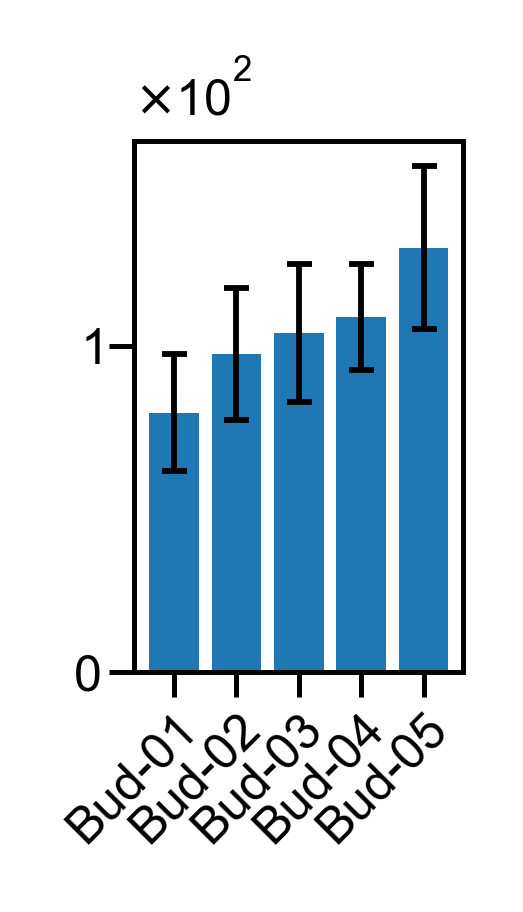

In [3]:
### FIGURE 7C (Bar Graph, old)

import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pinn.cme_analysis import plot_slice_summary_bar

# ==== Parameters =====
lambda_1 = 100000
lambda_2 = 1
lambda_3 = 100000
lambda_4 = 10
data_id = "jrc_cos7-1b"
shape_list = ["bud-12", "bud-11", "bud-09", "bud-07", "bud-10"]
labels = ["Bud-01", "Bud-02", "Bud-03", "Bud-04", "Bud-05"]
step = 10000
phase = 2
var = "fitted_radius"
# var = "H_mean"
# var = "K_std"

# ==== Import Data =====
ring = {}
stack = {}
for shape in shape_list:
    checkpoint_dir = f"../outputs/logs/{data_id}/unscaled/{shape}/phase{phase}_{lambda_1}_{lambda_2}_{lambda_3}_{lambda_4}"
    ring[shape] = np.load(f"{checkpoint_dir}/ring_{shape}.npz", allow_pickle=True)
    stack_npz = np.load(f"{checkpoint_dir}/stack_{shape}.npz", allow_pickle=True)
    stack[shape] = stack_npz 

plt.style.reload_library()
with plt.style.context(["base", "transparent"]):

    fig, ax = plot_slice_summary_bar(
        stack,
        var=var,
        reducer="max",
        shape_list=shape_list,
        only_positive_z=True,
        show_y_label=False,
        show_title=False,
        custom_labels=labels,
    )
    # fig.savefig(f"../outputs/figs/v_0321/experiment/{data_id}/bar_{var}.pdf")


In [30]:
def plot_shape_summary_bar(
    rows,
    var="radius_ratio",
    shape_list=None,
    ax=None,
    custom_labels=None,
    show_title=True,
    show_y_label=True,
):
    """
    Plot one summarized variable for each shape.

    Parameters
    ----------
    rows : list of dict
        Output from summarize_shapes_radius_ratio_vs_curvature_std().
    var : str
        Dictionary key to plot, such as:
        "radius_ratio", "H_std", "K_std",
        "neck_radius", or "max_fitted_radius".
    shape_list : list of str, optional
        Order in which shapes should be plotted.
    ax : matplotlib.axes.Axes, optional
        Existing axes on which to plot.
    custom_labels : list of str, optional
        Custom x-axis labels.
    show_title : bool
        Whether to show the title.
    show_y_label : bool
        Whether to show the y-axis label.
    """
    row_by_shape = {row["shape"]: row for row in rows}

    if shape_list is None:
        shape_list = [row["shape"] for row in rows]

    missing_shapes = [
        shape for shape in shape_list
        if shape not in row_by_shape
    ]
    if missing_shapes:
        raise ValueError(
            f"Shapes not found in rows: {missing_shapes}"
        )

    missing_vars = [
        shape for shape in shape_list
        if var not in row_by_shape[shape]
    ]
    if missing_vars:
        available_vars = sorted(
            set().union(*(row.keys() for row in rows))
        )
        raise ValueError(
            f"Variable {var!r} is missing for shapes: {missing_vars}. "
            f"Available variables: {available_vars}"
        )

    values = [
        float(row_by_shape[shape][var])
        for shape in shape_list
    ]

    x = np.arange(len(shape_list))

    if ax is None:
        fig, ax = plt.subplots(figsize=(0.9, 1.5))
    else:
        fig = ax.figure

    ax.bar(x, values)

    ax.set_xticks(x)

    if custom_labels is not None:
        if len(custom_labels) != len(shape_list):
            raise ValueError(
                "custom_labels must have the same length as shape_list."
            )

        ax.set_xticklabels(
            custom_labels,
            rotation=45,
            ha="right",
            rotation_mode="anchor",
        )
    else:
        ax.set_xticklabels(
            shape_list,
            rotation=45,
            ha="right",
            rotation_mode="anchor",
        )

    label_map = {
        "radius_ratio": r"$R_{\mathrm{max}} / R_{\mathrm{neck}}$",
        "H_std": r"Neck $\mathrm{std}(H)$",
        "K_std": r"Neck $\mathrm{std}(K)$",
        "neck_radius": r"$R_{\mathrm{neck}}$",
        "max_fitted_radius": r"$R_{\mathrm{max}}$",
    }

    y_label = label_map.get(var, var)

    if show_y_label:
        ax.set_ylabel(y_label)

    if show_title:
        ax.set_title(y_label)

    formatter = ticker.ScalarFormatter(useMathText=True)
    formatter.set_scientific(True)
    formatter.set_powerlimits((0, 0))
    ax.yaxis.set_major_formatter(formatter)

    fig.tight_layout()

    return fig, ax

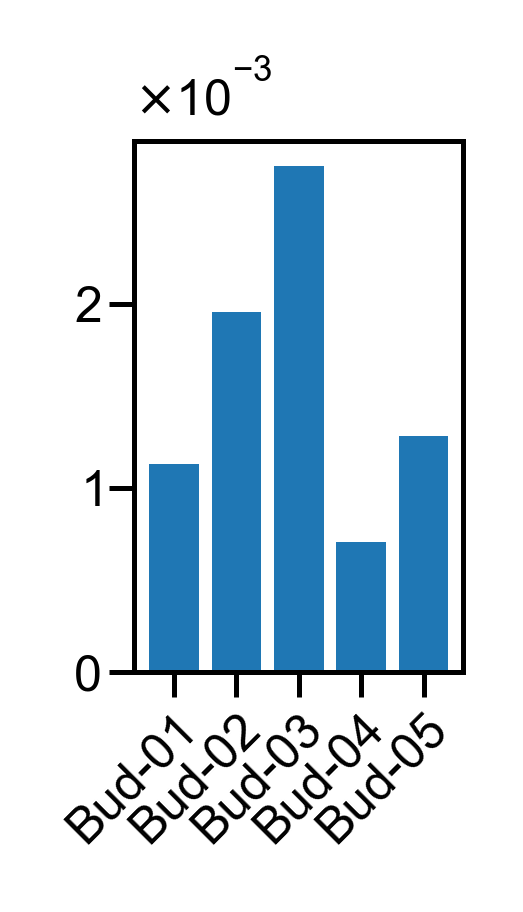

In [29]:
### FIGURE 7C (Bar Graph, new)

import os
import numpy as np
import matplotlib.pyplot as plt

from pinn.cme_analysis import (
    summarize_shapes_radius_ratio_vs_curvature_std,
    # plot_shape_summary_bar,
)

# ==== Parameters =====
lambda_1 = 100000
lambda_2 = 1
lambda_3 = 100000
lambda_4 = 10

data_id = "jrc_cos7-1b"
shape_list = ["bud-12", "bud-09", "bud-07", "bud-11", "bud-10"]
labels = ["Bud-01", "Bud-02", "Bud-03", "Bud-04", "Bud-05"]

phase = 2

# Available options:
# var = "radius_ratio"
var = "H_std"
# var = "K_std"
# var = "neck_radius"
# var = "max_fitted_radius"

# ==== Import Data =====
ring = {}
stack = {}

for shape in shape_list:
    checkpoint_dir = (f"../outputs/logs/{data_id}/unscaled/{shape}/phase{phase}_{lambda_1}_{lambda_2}_{lambda_3}_{lambda_4}")
    ring[shape] = np.load(f"{checkpoint_dir}/ring_{shape}.npz", allow_pickle=True)
    stack_npz = np.load(f"{checkpoint_dir}/stack_{shape}.npz", allow_pickle=True)

    if "stack" in stack_npz.files:
        stack[shape] = stack_npz["stack"].item()
    else:
        stack[shape] = stack_npz

# ==== Calculate Summary Variables =====
rows = summarize_shapes_radius_ratio_vs_curvature_std(
    shape_list=shape_list,
    ring_dict=ring,
    stack_dict=stack,
    curvature_source="ring",
)

# ==== Plot =====
plt.style.reload_library()

with plt.style.context(["base", "transparent"]):
    fig, ax = plot_shape_summary_bar(
        rows,
        var=var,
        shape_list=shape_list,
        custom_labels=labels,
        show_y_label=False,
        show_title=False,
    )

    plt.show()
    fig.savefig(
        f"../outputs/figs/v_0321/experiment/{data_id}/bar_new_{var}.pdf"
    )

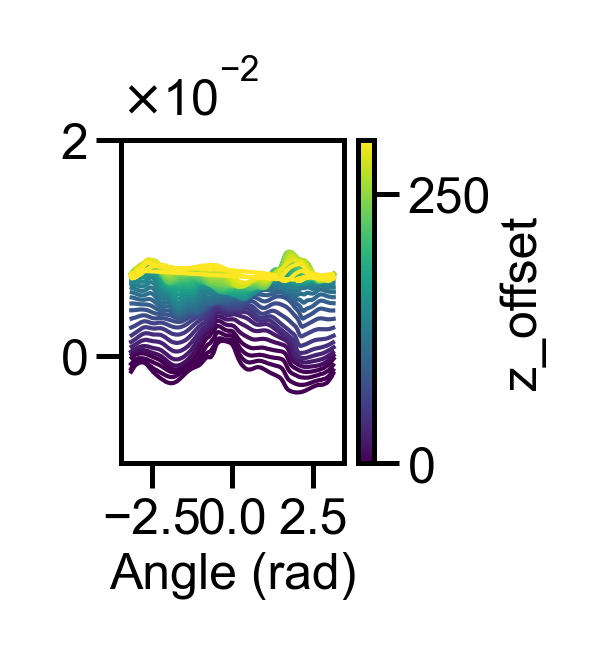

In [106]:
### FIGURE 7C (Bar Graph)

import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pinn.cme_analysis import plot_contour_property_vs_angle

# ==== Parameters =====
lambda_1 = 100000
lambda_2 = 1
lambda_3 = 100000
lambda_4 = 10
data_id = "jrc_cos7-1b"
shape_list = ["bud-12", "bud-11", "bud-09", "bud-07", "bud-10"]
label_list = ["Bud-01", "Bud-02", "Bud-03", "Bud-04", "Bud-05"]
step = 10000
phase = 2
curv = "curv"
# curv = "gauss"

if curv == "curv":
    ylim=(-0.01, 0.02)
elif curv == "gauss":
    ylim=(-0.0005, 0.0005)

# # ==== Import Data =====
# ring = {}
# stack = {}
# for shape in shape_list:
#     checkpoint_dir = f"../outputs/logs/{data_id}/unscaled/{shape}/phase{phase}_{lambda_1}_{lambda_2}_{lambda_3}_{lambda_4}"
#     ring[shape] = np.load(f"{checkpoint_dir}/ring_{shape}.npz", allow_pickle=True)
#     stack_npz = np.load(f"{checkpoint_dir}/stack_{shape}.npz", allow_pickle=True)
#     stack[shape] = stack_npz 


# # ==== Plot =====
# plt.style.reload_library()
# with plt.style.context(["base", "transparent"]):
#     for shape, label in zip(shape_list, label_list):

#         fig, ax = plot_contour_property_vs_angle(
#             stack[shape],
#             shape=shape,
#             prop=curv,
#             zmin=0, zmax=300,
#             ylim=ylim,
#             show_title=False,
#             show_legend=False,
#             show_y_label=False,
#             angle_unit="rad"
#         )

#         fig.savefig(f"../outputs/figs/v_0321/experiment/{data_id}/curv_{curv}_{label}.pdf",bbox_inches="tight")
#         plt.close(fig)


plt.style.reload_library()
with plt.style.context(["base", "transparent"]):
    fig, ax = plot_contour_property_vs_angle(
        stack[shape],
        shape=shape,
        prop=curv,
        zmin=0, zmax=300,
        ylim=ylim,
        show_title=False,
        # show_legend=False,
        show_y_label=False,
        angle_unit="rad"
    )

    fig.savefig(f"../outputs/figs/v_0321/experiment/{data_id}/curv_legend.pdf",bbox_inches="tight")
    # plt.close(fig)

In [102]:
## To reload

import importlib
# import pinn.plot as plot
# import data_generation.preprocess as preprocess
# import pinn.utils as utils
# import pinn.analysis as analysis
# import pinn.normal_curves as normal_curves
import pinn.cme_analysis as cme

# importlib.reload(plot)
# importlib.reload(utils)
# importlib.reload(preprocess)
# importlib.reload(analysis)
# importlib.reload(normal_curves)
importlib.reload(cme)

<module 'pinn.cme_analysis' from '/mmfs1/gscratch/matsulab/sim/pinn-exploration-model/notebooks/../src/pinn/cme_analysis.py'>

In [8]:
print(gauss_cor)
print(curvs_cor)

{0: {0.0: 0.9244818885402216, 0.6: 0.8535116177619742, 0.7: 0.6465199750764272, 0.8: 0.49500322786870626, 0.9: 0.18860733510253283}, 10: {0.0: 0.9009007383677825, 0.6: 0.910460662216215, 0.7: 0.857685975579007, 0.8: 0.8762844237287911, 0.9: 0.7310608682144887}}
{0: {0.0: 0.9171896169116767, 0.6: 0.8392043833904753, 0.7: 0.6797124713365718, 0.8: 0.5679632324479695, 0.9: 0.19767679659891413}, 10: {0.0: 0.8925097725494212, 0.6: 0.899859829733756, 0.7: 0.8527740642529489, 0.8: 0.8649522237751068, 0.9: 0.7114996349772}}
